<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate_(Notebook_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")

All libraries installed.


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [3]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers as KL
import math
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)
from sklearn.tree          import DecisionTreeClassifier
from sklearn.metrics       import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay, log_loss,
    classification_report, average_precision_score
)
from sklearn.model_selection import learning_curve

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 4: SETUP — restores state from Notebook 3              ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
This is a brand-new Colab runtime, so libraries must be reinstalled,
imports re-run, and Google Drive remounted (Cells 1-3 below are copied
VERBATIM from the original notebook — nothing in them has changed).

After that, this cell restores every variable Notebook 3 produced,
so the original Cell 27 further down can run exactly as
written, unchanged, picking up right where Notebook 3 left off.
"""
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_3_to_4"

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "rb") as f:
    _state = dill.load(f)
globals().update(_state)

with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json") as f:
    _keras_paths = json.load(f)
for _name, _path in _keras_paths.items():
    globals()[_name] = keras.models.load_model(_path)

print("=" * 65)
print(f"CHECKPOINT RESTORED <- {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 3 state loaded successfully.")
print("Continuing from Cell 27 below, unchanged.")


CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_3_to_4.pkl
  Variables restored    : 367
  Keras models restored : ['mlp_base_model', 'mlp_tuned']
  df_combined shape      : (149999, 51)

Notebook 3 state loaded successfully.
Continuing from Cell 27 below, unchanged.


CELL 25 — BASELINE vs TUNED COMPARISON (Validation Set)
        Model  Baseline R²  Tuned R²    ΔR²  Baseline RMSE  Tuned RMSE  ΔRMSE Tuned RealMAE
Random Forest       0.7456    0.7495 0.0038         0.4871      0.4834 0.0037       $58,090
     CatBoost       0.7276    0.7428 0.0152         0.5041      0.4898 0.0143       $65,008
          MLP       0.7108    0.7184 0.0076         0.5194      0.5126 0.0068       $72,607
          HGB       0.7341    0.7436 0.0094         0.4980      0.4891 0.0089       $65,437


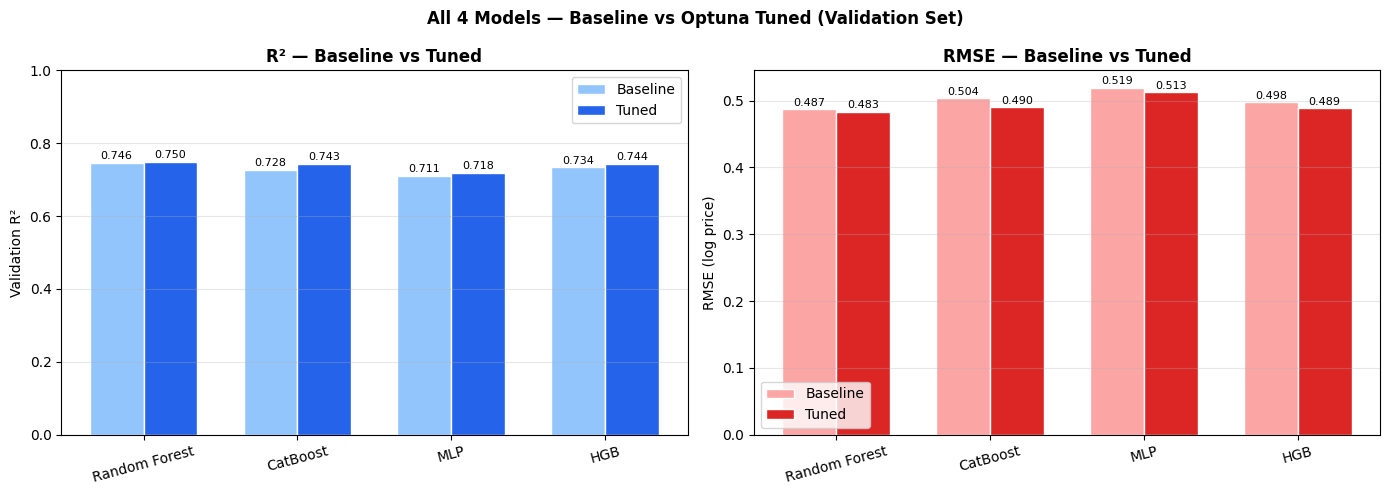

Chart saved → /content/drive/MyDrive/RealEstate_TXNY/comparison_baseline_tuned.png


In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 25 — BEFORE vs AFTER TUNING COMPARISON TABLE               ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Builds a comparison table and 2-panel bar chart for all 4 models.

Comparison table:
    Model          Baseline R²  Tuned R²    ΔR²   Tuned RealMAE
    Random Forest  0.7456       0.7495    +0.0038  $58,090
    CatBoost       0.7276       0.7428    +0.0152  $65,008
    MLP            0.7108       0.7184    +0.0076  $72,607
    HGB            0.7341       0.7436    +0.0094  $65,437

2-panel bar chart:
    Panel 1 (left)  — R² grouped bars: Baseline (light blue) vs Tuned (dark blue)
    Panel 2 (right) — RMSE grouped bars: Baseline (light red) vs Tuned (dark red)
    Value labels on top of each bar.
    model_names = ["Random Forest", "CatBoost", "MLP", "HGB"]
    Width = 0.35, offset ±width/2.

Output:
    comp_df (pd.DataFrame)   : 4-row comparison table
    Saved to: SAVE_DIR/comparison_baseline_tuned.png
"""

print("=" * 65)
print("CELL 25 — BASELINE vs TUNED COMPARISON (Validation Set)")
print("=" * 65)

comparison_rows = []
model_names = ["Random Forest","CatBoost","MLP","HGB"]
for i, (bl, tu) in enumerate(zip(results_baseline, results_tuned)):
    comparison_rows.append({
        "Model":          model_names[i],
        "Baseline R²":    round(bl["R2"],   4),
        "Tuned R²":       round(tu["R2"],   4),
        "ΔR²":            round(tu["R2"] - bl["R2"], 4),
        "Baseline RMSE":  round(bl["RMSE"], 4),
        "Tuned RMSE":     round(tu["RMSE"], 4),
        "ΔRMSE":          round(bl["RMSE"] - tu["RMSE"], 4),
        "Tuned RealMAE":  f"${tu['Real_MAE_USD']:,.0f}",
    })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

# Visual bar chart
fig_comp, axes_c = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(model_names))
width = 0.35

ax_r2 = axes_c[0]
bl_r2 = [r["Baseline R²"] for r in comparison_rows]
tu_r2 = [r["Tuned R²"]    for r in comparison_rows]
ax_r2.bar(x_pos - width/2, bl_r2, width, label="Baseline", color="#93C5FD", edgecolor="white")
ax_r2.bar(x_pos + width/2, tu_r2, width, label="Tuned",    color="#2563EB", edgecolor="white")
ax_r2.set_xticks(x_pos); ax_r2.set_xticklabels(model_names, rotation=15)
ax_r2.set_ylabel("Validation R²"); ax_r2.set_ylim(0, 1)
ax_r2.set_title("R² — Baseline vs Tuned", fontweight="bold")
ax_r2.legend(); ax_r2.grid(axis="y", alpha=0.3)
for i, (b, t) in enumerate(zip(bl_r2, tu_r2)):
    ax_r2.text(i - width/2, b + 0.01, f"{b:.3f}", ha="center", fontsize=8)
    ax_r2.text(i + width/2, t + 0.01, f"{t:.3f}", ha="center", fontsize=8)

ax_rm = axes_c[1]
bl_rm = [r["Baseline RMSE"] for r in comparison_rows]
tu_rm = [r["Tuned RMSE"]    for r in comparison_rows]
ax_rm.bar(x_pos - width/2, bl_rm, width, label="Baseline", color="#FCA5A5", edgecolor="white")
ax_rm.bar(x_pos + width/2, tu_rm, width, label="Tuned",    color="#DC2626", edgecolor="white")
ax_rm.set_xticks(x_pos); ax_rm.set_xticklabels(model_names, rotation=15)
ax_rm.set_ylabel("RMSE (log price)"); ax_rm.set_title("RMSE — Baseline vs Tuned", fontweight="bold")
ax_rm.legend(); ax_rm.grid(axis="y", alpha=0.3)
for i, (b, t) in enumerate(zip(bl_rm, tu_rm)):
    ax_rm.text(i - width/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=8)
    ax_rm.text(i + width/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=8)

plt.suptitle("All 4 Models — Baseline vs Optuna Tuned (Validation Set)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/comparison_baseline_tuned.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {SAVE_DIR}/comparison_baseline_tuned.png")

In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 26 -  5-FOLD OUT-OF-FOLD (OOF) PREDICTIONS                 ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Generates OOF predictions for all 4 tuned models for Ridge stacking.

OOF generation loop:
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    For each fold (tri=training indices, vli=validation indices):

    Fold data slices:
        Xf_tr = Xtr_rf[tri]   Xf_va = Xtr_rf[vli]  → for RF, CatBoost
        Xs_tr = Xtr_sc[tri]   Xs_va = Xtr_sc[vli]  → for MLP
        Xr_tr = Xtr_raw[tri]  Xr_va = Xtr_raw[vli] → for HGB (native NaN)
        yt    = yr_train_vals[tri]
        ys_tr = norm_y(yt)    ys_va = norm_y(yv)   → normalised for MLP

    Per-fold model training:
        RF fold  : RandomForestRegressor(rf_bp params) → fit → predict
        CB fold  : CatBoostRegressor(cb_bp params)     → fit → predict
        MLP fold : build_residual_mlp(bp_mlp params)   → fit → denorm_y(predict)
        HGB fold : HistGradientBoostingRegressor(hgb_bp, early_stopping=False) → fit → predict

    OOF fill:
        oof_rf[vli]  = rf_f.predict(Xf_va)
        oof_cat[vli] = cat_f.predict(Xf_va)
        oof_mlp[vli] = denorm_y(mlp_f.predict(Xs_va))
        oof_hgb[vli] = hgb_f.predict(Xr_va)

OOF stability check:
    MLP_THRESHOLD = 0.50
    mlp_oof_r2 = r2_score(yr_train_vals, oof_mlp)
    If mlp_oof_r2 < 0.50: exclude MLP from stack
    If mlp_oof_r2 >= 0.50: include MLP

Output variables:
    oof_rf   (np.ndarray) : shape (n_train,) RF OOF predictions
    oof_cat  (np.ndarray) : shape (n_train,) CatBoost OOF predictions
    oof_mlp  (np.ndarray) : shape (n_train,) MLP OOF predictions (denormalised)
    oof_hgb  (np.ndarray) : shape (n_train,) HGB OOF predictions
    INCLUDE_MLP_IN_STACK (bool) : True ─ MLP OOF R² above threshold
    mlp_oof_r2 (float)   : 0.7395
    MLP_THRESHOLD (float): 0.50
"""

print("=" * 65)
print("CELL 26 ─ 5-FOLD OOF PREDICTIONS (ALL 4 TUNED MODELS)")
print("=" * 65)

kf      = KFold(n_splits=5, shuffle=True, random_state=SEED)
n_train = len(X_train)
oof_rf  = np.zeros(n_train)
oof_cat = np.zeros(n_train)
oof_mlp = np.zeros(n_train)
oof_hgb = np.zeros(n_train)

yr_train_vals = y_reg_train.values

for fold_idx, (tri, vli) in enumerate(kf.split(Xtr_rf)):
    print(f"\n  ── FOLD {fold_idx+1}/5 "
          f"(train={len(tri):,}  val={len(vli):,}) ──────────────────")

    # ── Fold data slices ────────────────────
    Xf_tr = Xtr_rf[tri];   Xf_va = Xtr_rf[vli]
    Xs_tr = Xtr_sc[tri];   Xs_va = Xtr_sc[vli]
    Xr_tr = Xtr_raw[tri];  Xr_va = Xtr_raw[vli]
    yf_tr = yr_train_vals[tri]
    yf_va = yr_train_vals[vli]
    ys_tr = norm_y(yf_tr); ys_va = norm_y(yf_va)

    # ── RF fold ─────────────
    rf_f = RandomForestRegressor(
        n_estimators    = rf_bp["n_est"],
        max_depth       = rf_bp["depth"],
        min_samples_leaf= rf_bp["min_leaf"],
        max_features    = rf_bp["max_f"],
        n_jobs=-1, random_state=SEED)
    rf_f.fit(Xf_tr, yf_tr)
    oof_rf[vli] = rf_f.predict(Xf_va)
    print(f"    RF       R²: {r2_score(yf_va, oof_rf[vli]):.4f}")

    # ── CatBoost fold ─────────────
    cat_f = CatBoostRegressor(
        iterations    = cb_bp["iters"],
        learning_rate = cb_bp["lr"],
        depth         = cb_bp["depth"],
        l2_leaf_reg   = cb_bp["l2"],
        subsample     = cb_bp["sub"],
        random_seed=SEED, verbose=0)
    cat_f.fit(Xf_tr, yf_tr)
    oof_cat[vli] = cat_f.predict(Xf_va)
    print(f"    CatBoost R²: {r2_score(yf_va, oof_cat[vli]):.4f}")

    # ── MLP fold ─────────────
    mlp_f = build_residual_mlp(
        bp_mlp["u1"], bp_mlp["u2"], bp_mlp["dr"], bp_mlp["l2"], n_feat)
    mlp_f.compile(
        optimizer=keras.optimizers.Adam(bp_mlp["lr"], clipnorm=1.0),
        loss=keras.losses.Huber(delta=bp_mlp["delta"]))
    fold_lr_cb = keras.callbacks.LearningRateScheduler(
        lambda ep: cosine_lr(ep, N_MLP_EPOCHS, lr_max=bp_mlp["lr"])) # Pass lr_min explicitly
    mlp_f.fit(Xs_tr, ys_tr,
               validation_data=(Xs_va, ys_va),
               epochs=N_MLP_EPOCHS, batch_size=bp_mlp["bs"], verbose=0,
               callbacks=[
                   keras.callbacks.EarlyStopping(
                       patience=15, min_delta=1e-4, restore_best_weights=True),
                   keras.callbacks.ReduceLROnPlateau(
                       monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
                   fold_lr_cb,
               ])
    oof_mlp[vli] = denorm_y(mlp_f.predict(Xs_va, verbose=0).flatten())
    print(f"    MLP      R²: {r2_score(yf_va, oof_mlp[vli]):.4f}")

    # ── HGB fold ─────────────
    hgb_f = HistGradientBoostingRegressor(
        learning_rate    = hgb_bp["lr"],
        max_iter         = hgb_bp["max_iter"],
        max_depth        = hgb_bp["depth"],
        min_samples_leaf = hgb_bp["min_leaf"],
        l2_regularization= hgb_bp["l2"],
        max_bins         = hgb_bp["bins"],
        early_stopping   = False,
        random_state=SEED)
    hgb_f.fit(Xr_tr, yf_tr)
    oof_hgb[vli] = hgb_f.predict(Xr_va)
    print(f"    HGB      R²: {r2_score(yf_va, oof_hgb[vli]):.4f}")

# ── OOF summary ─────────────────────────
print(f"\n{'='*65}")
print("OOF R² SUMMARY (full training set)")
print("="*65)
oof_models = [("Random Forest",  oof_rf),
              ("CatBoost",       oof_cat),
              ("MLP (residual)", oof_mlp),
              ("HGB",            oof_hgb),]
oof_results = []
for name, oof_arr in oof_models:
    r2_oof   = r2_score(yr_train_vals, oof_arr)
    rmse_oof = np.sqrt(mean_squared_error(yr_train_vals, oof_arr))
    oof_results.append({"Model": name, "OOF R²": round(r2_oof,4),
                         "OOF RMSE": round(rmse_oof,4)})
    print(f"  {name:22s}  OOF R²={r2_oof:.4f}  OOF RMSE={rmse_oof:.4f}")

# Check MLP OOF stability flag
mlp_oof_r2 = r2_score(yr_train_vals, oof_mlp)
MLP_THRESHOLD = 0.50
print(f"\nMLP OOF R²={mlp_oof_r2:.4f}  threshold={MLP_THRESHOLD}")
if mlp_oof_r2 >= MLP_THRESHOLD:
    print("  MLP is stable ─ will be included in Ridge stacking ")
    INCLUDE_MLP_IN_STACK = True
else:
    print("  MLP OOF R² below threshold ─ will be EXCLUDED from stack")
    print("  (Ridge will still see RF + CatBoost + HGB)")
    INCLUDE_MLP_IN_STACK = False

CELL 26 ─ 5-FOLD OOF PREDICTIONS (ALL 4 TUNED MODELS)

  ── FOLD 1/5 (train=95,999  val=24,000) ──────────────────
    RF       R²: 0.8053
    CatBoost R²: 0.7979
    MLP      R²: 0.7804
    HGB      R²: 0.8003

  ── FOLD 2/5 (train=95,999  val=24,000) ──────────────────
    RF       R²: 0.7863
    CatBoost R²: 0.7791
    MLP      R²: 0.7591
    HGB      R²: 0.7815

  ── FOLD 3/5 (train=95,999  val=24,000) ──────────────────
    RF       R²: 0.7950
    CatBoost R²: 0.7852
    MLP      R²: 0.7307
    HGB      R²: 0.7865

  ── FOLD 4/5 (train=95,999  val=24,000) ──────────────────
    RF       R²: 0.7815
    CatBoost R²: 0.7723
    MLP      R²: 0.7573
    HGB      R²: 0.7742

  ── FOLD 5/5 (train=96,000  val=23,999) ──────────────────
    RF       R²: 0.7702
    CatBoost R²: 0.7724
    MLP      R²: 0.7425
    HGB      R²: 0.7674

OOF R² SUMMARY (full training set)
  Random Forest           OOF R²=0.7875  OOF RMSE=0.4517
  CatBoost                OOF R²=0.7813  OOF RMSE=0.4583
  MLP (resi